# Import libraries and data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from itertools import combinations

# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Read the data
wine = pd.read_csv('C:/Users/Katlego/OneDrive/Desktop/Data/CSIS3754/wine.csv')

print("="*60)
print("3.1: DATA LOADING")
print("="*60)
print("Data loaded successfully.")
print(f"Dataset shape: {wine.shape}")
print(f"\nFirst 5 records:")
print(wine.head())
print(f"\nColumn names:")
print(wine.columns.tolist())

3.1: DATA LOADING
Data loaded successfully.
Dataset shape: (178, 13)

First 5 records:
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD

# Ensure no zero values

In [2]:
# Check for zero values in each column
zero_counts = (wine == 0).sum()
print("Zero values per column:")
print(zero_counts)

# Check for any zero values in the dataset
total_zeros = zero_counts.sum()
print(f"\nTotal zero values in dataset: {total_zeros}")

if total_zeros == 0:
    print("\n✓ No zero values found in the dataset. The data is clean.")
else:
    print(f"\n⚠️ Found {total_zeros} zero values in the dataset.")
    # Identify columns with zeros
    columns_with_zeros = zero_counts[zero_counts > 0].index.tolist()
    print(f"Columns containing zeros: {columns_with_zeros}")
    
    # For wine dataset, zeros may represent actual measurements (e.g., Proanthocyanins)
    # rather than missing data. We will leave them as is since they are valid.
    print("\nNOTE: In wine datasets, zero values may be valid measurements")
    print("(e.g., some wines may have zero Proanthocyanins).")
    print("No imputation will be performed as zeros are considered valid data points.")

# Display basic statistics to understand the data distribution
print("\n" + "="*60)
print("BASIC STATISTICS (for reference)")
print("="*60)
print(wine.describe())

Zero values per column:
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Total zero values in dataset: 0

✓ No zero values found in the dataset. The data is clean.

BASIC STATISTICS (for reference)
          Alcohol  Malic_Acid         Ash  Ash_Alcanity   Magnesium  \
count  178.000000  178.000000  178.000000    178.000000  178.000000   
mean    13.000618    2.336348    2.366517     19.494944   99.741573   
std      0.811827    1.117146    0.274344      3.339564   14.282484   
min     11.030000    0.740000    1.360000     10.600000   70.000000   
25%     12.362500    1.602500    2.210000     17.200000   88.000000   
50%     13.050000    1.865000    2.360000     19.500000   98.000000   
75

#  k-Means Clustering

Selected features: ['Alcohol', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Color_Intensity']

Feature matrix shape: (178, 5)
First 5 rows of feature matrix:
   Alcohol  Magnesium  Total_Phenols  Flavanoids  Color_Intensity
0    14.23        127           2.80        3.06             5.64
1    13.20        100           2.65        2.76             4.38
2    13.16        101           2.80        3.24             5.68
3    14.37        113           3.85        3.49             7.80
4    13.24        118           2.80        2.69             4.32

--- PRE-PROCESSING: STANDARDIZATION ---
Features have been standardized (mean=0, std=1).
Scaled data shape: (178, 5)

--- DETERMINING OPTIMAL k USING SILHOUETTE SCORE ---
k=2: Silhouette Score = 0.3129
k=3: Silhouette Score = 0.3590
k=4: Silhouette Score = 0.3722
k=5: Silhouette Score = 0.3126
k=6: Silhouette Score = 0.2680
k=7: Silhouette Score = 0.2764
k=8: Silhouette Score = 0.2671
k=9: Silhouette Score = 0.2624
k=10: Silhouette Score = 0

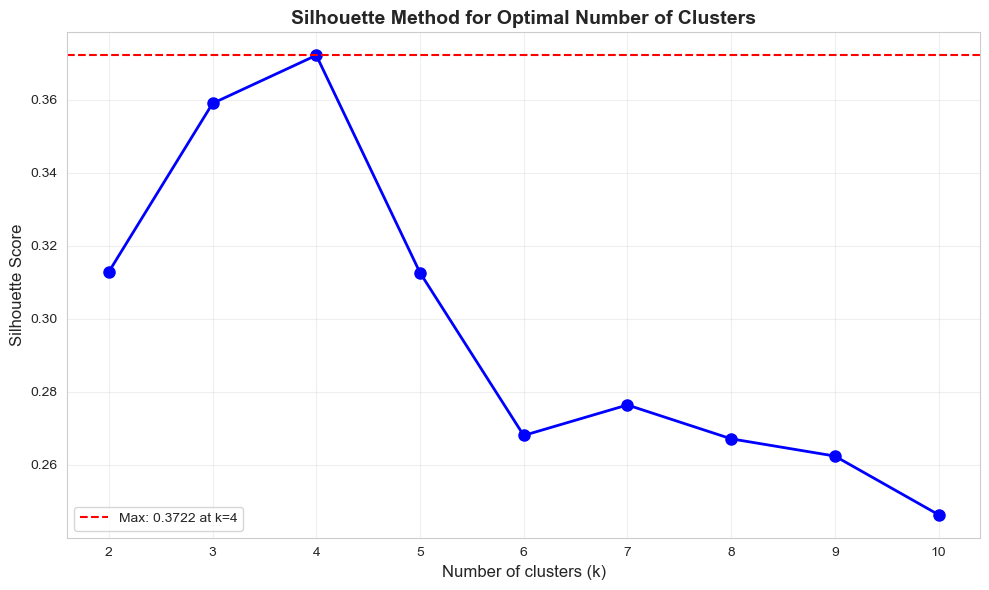


Optimal number of clusters (k): 4

--- TRAINING K-MEANS MODEL ---
Model trained successfully with k=4.

--- CLUSTER LABELS (first 30 samples) ---
0     2
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     2
9     2
10    2
11    2
12    2
13    2
14    2
15    2
16    2
17    2
18    2
19    2
20    2
21    1
22    2
23    1
24    2
25    2
26    2
27    1
28    2
29    2

--- CLUSTER CENTERS (in original scale) ---
     Alcohol   Magnesium  Total_Phenols  Flavanoids  Color_Intensity
0  12.445000  140.666667       2.110000    1.755000         3.133333
1  12.295758   91.045455       2.190909    1.993788         3.018939
2  13.712034  105.847458       2.907797    3.082881         5.584237
3  13.168298   99.063830       1.695957    0.791489         7.506808

--- CLUSTER CENTERS (standardized scale) ---
    Alcohol  Magnesium  Total_Phenols  Flavanoids  Color_Intensity
0 -0.686335   2.873488      -0.296611   -0.275358        -0.832592
1 -0.870689  -0.610584      -0.166968   -0.

In [3]:
# 3.3.1 Select only the specified features
selected_features = ['Alcohol', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Color_Intensity']
print(f"Selected features: {selected_features}")

# Extract the features
X = wine[selected_features].copy()
print(f"\nFeature matrix shape: {X.shape}")
print(f"First 5 rows of feature matrix:")
print(X.head())

# 3.3.2 Pre-processing - Standardization
print("\n--- PRE-PROCESSING: STANDARDIZATION ---")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features have been standardized (mean=0, std=1).")
print(f"Scaled data shape: {X_scaled.shape}")

# 3.3.3 Determine the best value for k using silhouette score
print("\n--- DETERMINING OPTIMAL k USING SILHOUETTE SCORE ---")
silhouette_scores = []
K_range = range(2, 11)  # Test k from 2 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Method for Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=max(silhouette_scores), color='r', linestyle='--', 
            label=f'Max: {max(silhouette_scores):.4f} at k={K_range[np.argmax(silhouette_scores)]}')
plt.legend()
plt.tight_layout()
plt.show()

# Get optimal k
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters (k): {optimal_k}")

# 3.3.4 Train the model with optimal k
print("\n--- TRAINING K-MEANS MODEL ---")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
wine['Cluster'] = kmeans.fit_predict(X_scaled)
print(f"Model trained successfully with k={optimal_k}.")

# 3.3.5 Print the labels of the trained model
print("\n--- CLUSTER LABELS (first 30 samples) ---")
print(wine['Cluster'].head(30).to_string())

# 3.3.6 Print the cluster centres
print("\n--- CLUSTER CENTERS (in original scale) ---")
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=selected_features)
print(centers_df)

# Also print centers in standardized scale for reference
print("\n--- CLUSTER CENTERS (standardized scale) ---")
centers_std_df = pd.DataFrame(kmeans.cluster_centers_, columns=selected_features)
print(centers_std_df)

# Display cluster distribution
print("\n--- CLUSTER DISTRIBUTION ---")
cluster_counts = wine['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} samples ({count/len(wine)*100:.1f}%)")

# Visualise clusters with scatter plots

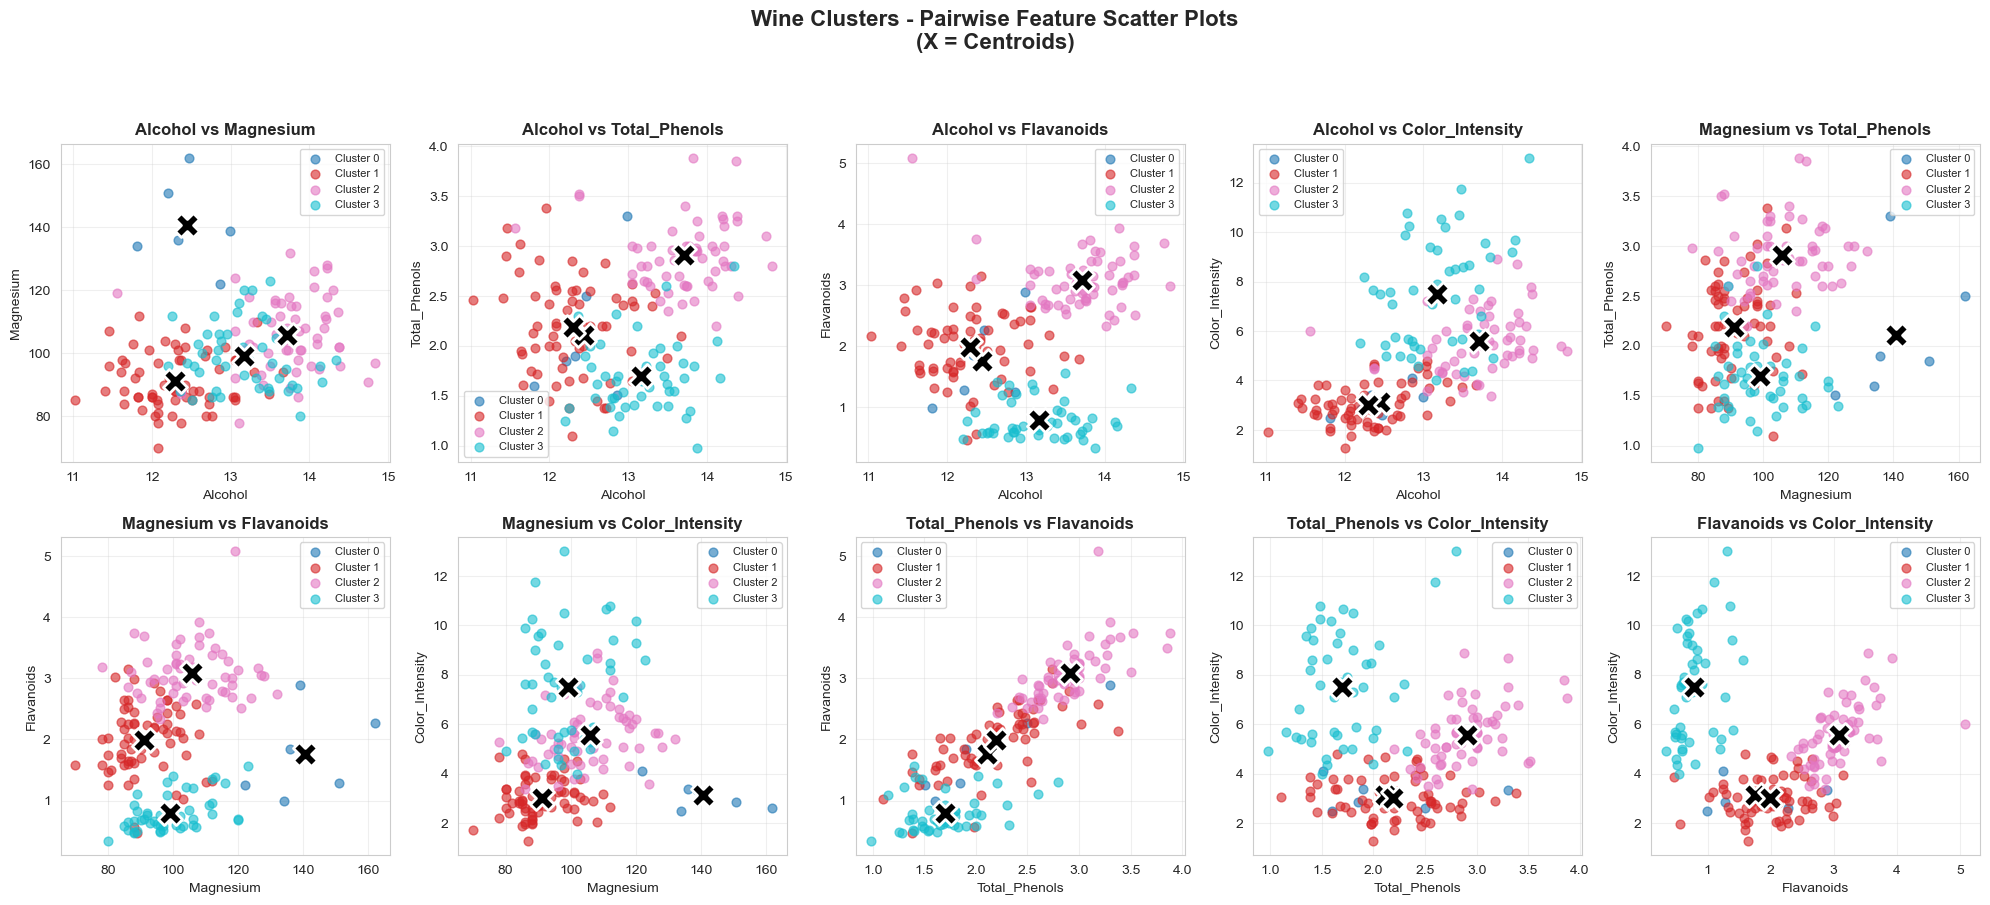


--- ADDITIONAL VISUALISATION: PAIRPLOT ---


<Figure size 1500x1500 with 0 Axes>

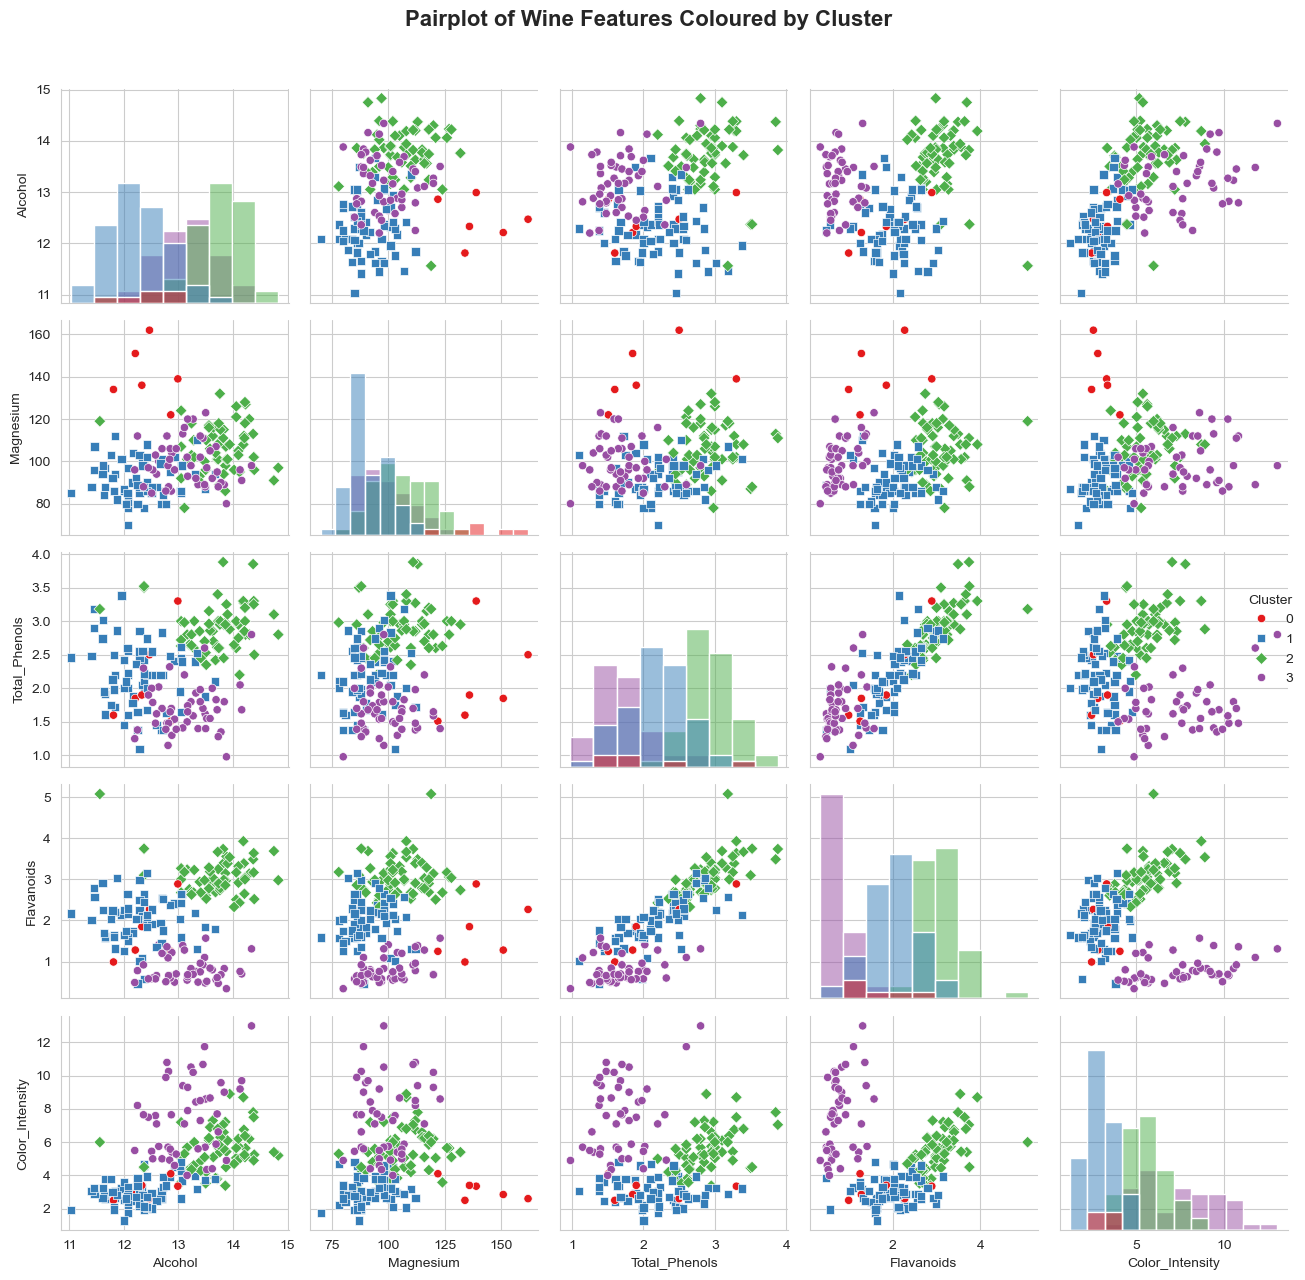

In [4]:
# Create scatter plots between different pairs of features (10 plots)
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
feature_pairs = list(combinations(selected_features, 2))

# Define a color palette for clusters
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))

# Create a mapping for cluster colors
cluster_colors = {i: colors[i] for i in range(optimal_k)}

for idx, (feat1, feat2) in enumerate(feature_pairs):
    row = idx // 5
    col = idx % 5
    
    # Plot each cluster with different colours
    for cluster_id in range(optimal_k):
        cluster_data = wine[wine['Cluster'] == cluster_id]
        axes[row, col].scatter(cluster_data[feat1], cluster_data[feat2], 
                              label=f'Cluster {cluster_id}', 
                              alpha=0.6, 
                              color=colors[cluster_id], 
                              s=40)
        
        # Plot centroids
        centroid_row = centers_df.iloc[cluster_id]
        axes[row, col].scatter(centroid_row[feat1], centroid_row[feat2], 
                              marker='X', s=300, color='black', 
                              edgecolors='white', linewidth=2, zorder=10)
    
    axes[row, col].set_xlabel(feat1, fontsize=10)
    axes[row, col].set_ylabel(feat2, fontsize=10)
    axes[row, col].set_title(f'{feat1} vs {feat2}', fontsize=12, fontweight='bold')
    axes[row, col].grid(True, alpha=0.3)
    axes[row, col].legend(loc='best', fontsize=8)

# Hide unused subplots (since we have 10 plots but 25 subplots)
for idx in range(len(feature_pairs), 25):
    row = idx // 5
    col = idx % 5
    axes[row, col].set_visible(False)

plt.suptitle('Wine Clusters - Pairwise Feature Scatter Plots\n(X = Centroids)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Also create a pairplot for a different perspective
print("\n--- ADDITIONAL VISUALISATION: PAIRPLOT ---")
plt.figure(figsize=(15, 15))
g = sns.pairplot(data=wine, vars=selected_features, hue='Cluster', 
                 palette='Set1', diag_kind='hist', markers=['o', 's', 'D'])
g.fig.suptitle('Pairplot of Wine Features Coloured by Cluster', 
               fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Selected features: ['Alcohol', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Color_Intensity']
Number of feature pairs: 10

Centroid coordinates (original scale):
     Alcohol   Magnesium  Total_Phenols  Flavanoids  Color_Intensity
0  12.445000  140.666667       2.110000    1.755000         3.133333
1  12.295758   91.045455       2.190909    1.993788         3.018939
2  13.712034  105.847458       2.907797    3.082881         5.584237
3  13.168298   99.063830       1.695957    0.791489         7.506808

--- GENERATING 10 SCATTER PLOTS ---


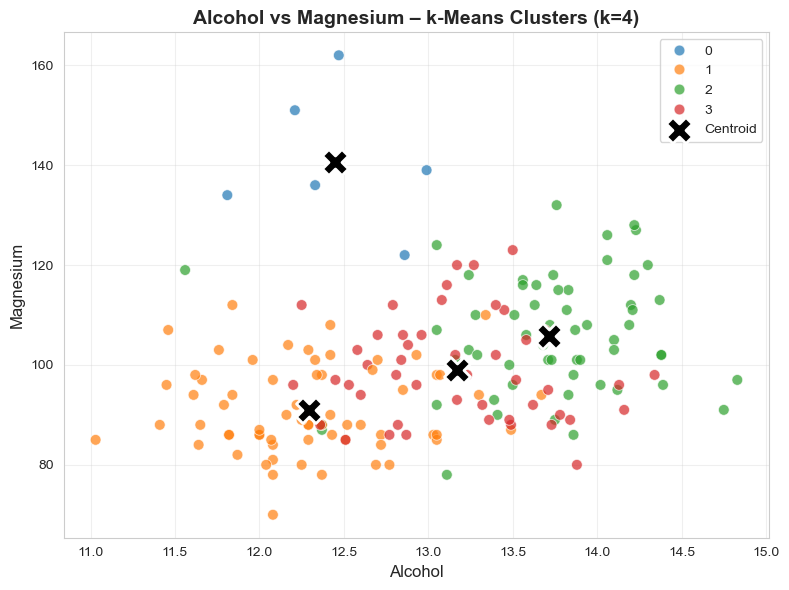

Insight: Alcohol vs Magnesium shows good cluster separation with centroids positioned appropriately.


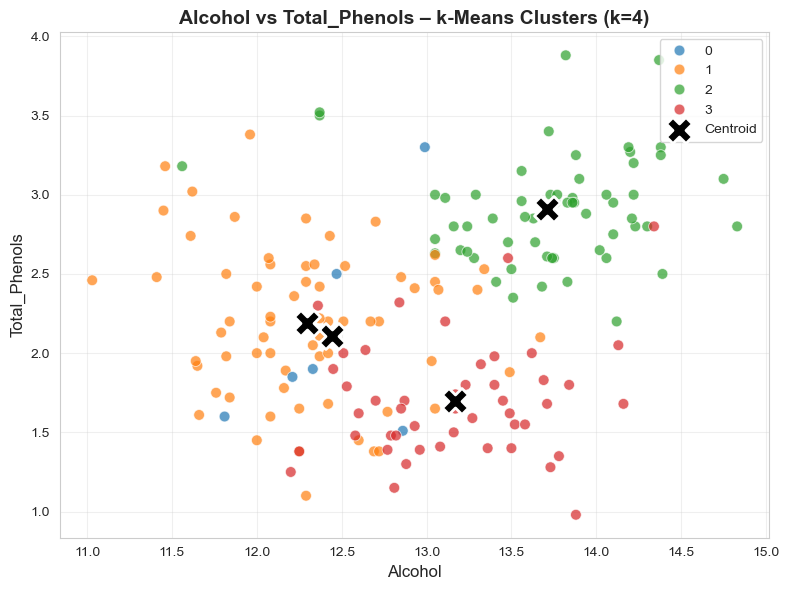

Insight: Alcohol vs Total_Phenols shows good cluster separation with centroids positioned appropriately.


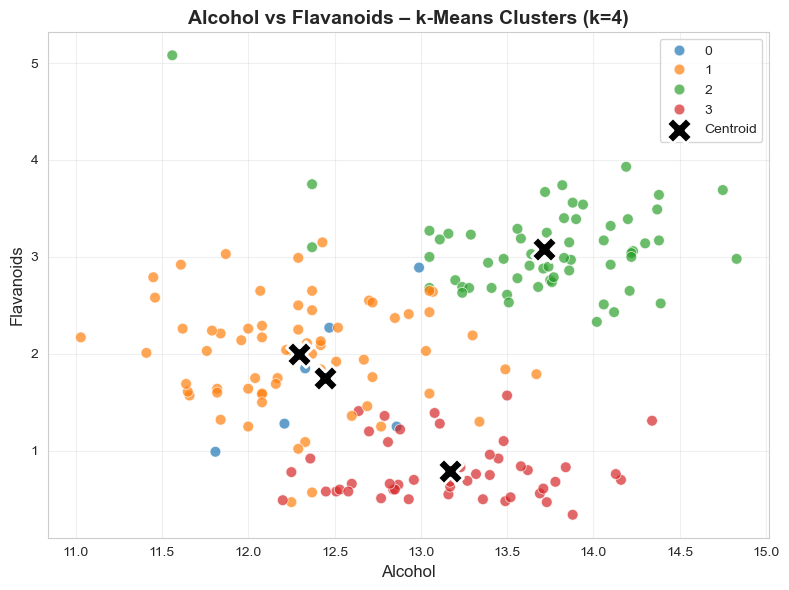

Insight: Alcohol vs Flavanoids shows good cluster separation with centroids positioned appropriately.


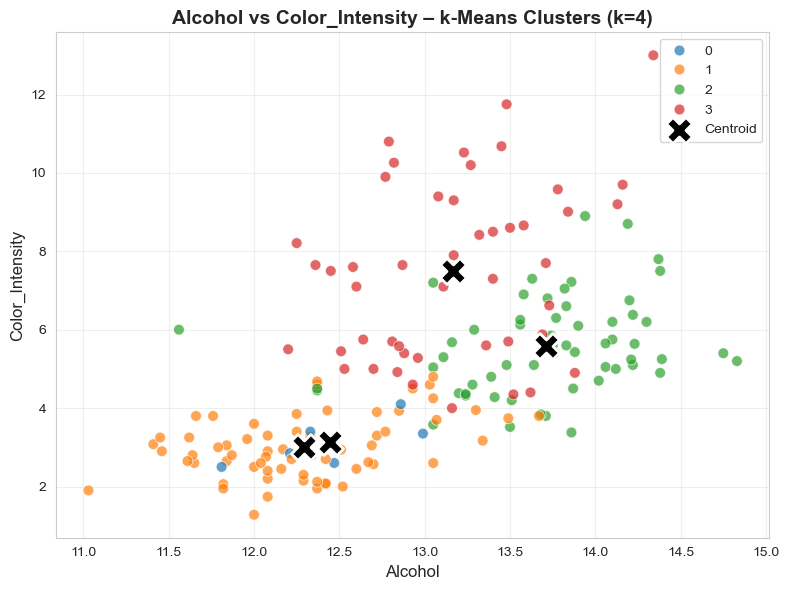

Insight: Alcohol vs Color_Intensity shows good cluster separation with centroids positioned appropriately.


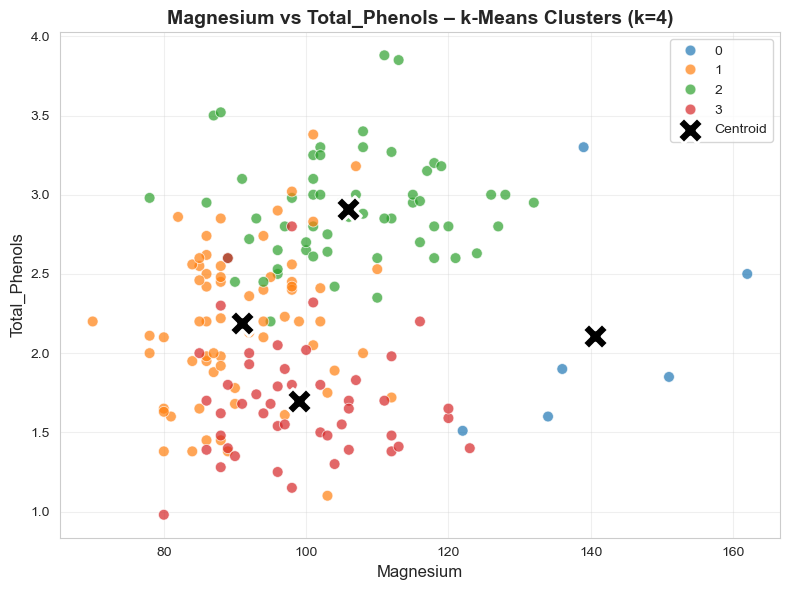

Insight: Magnesium vs Total_Phenols shows good cluster separation with centroids positioned appropriately.


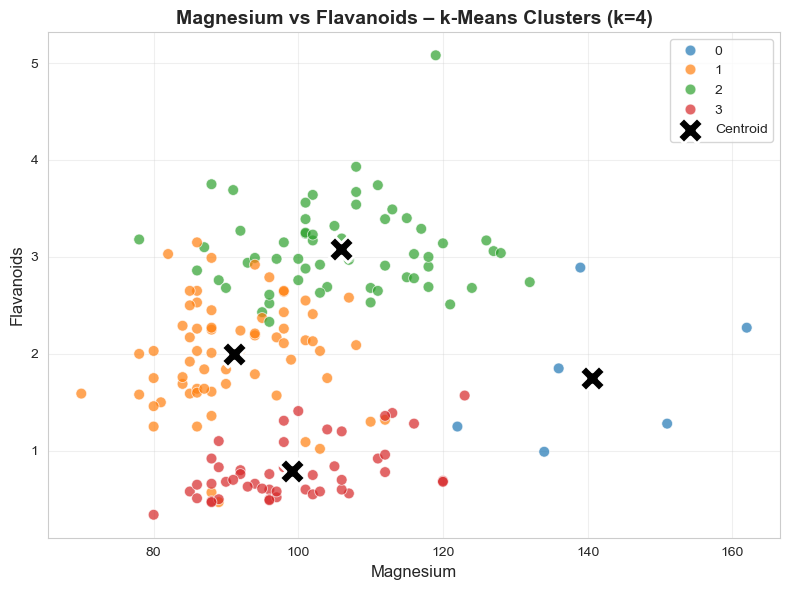

Insight: Magnesium vs Flavanoids shows good cluster separation with centroids positioned appropriately.


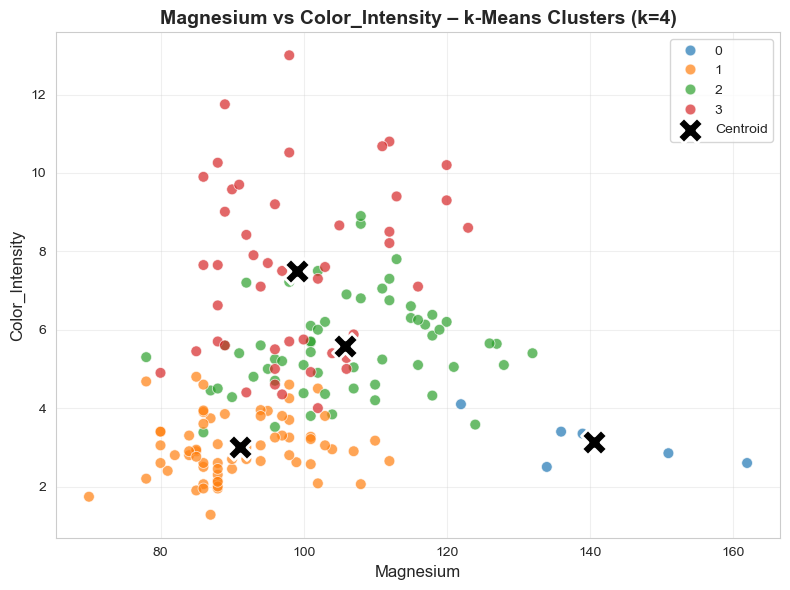

Insight: Magnesium vs Color_Intensity shows good cluster separation with centroids positioned appropriately.


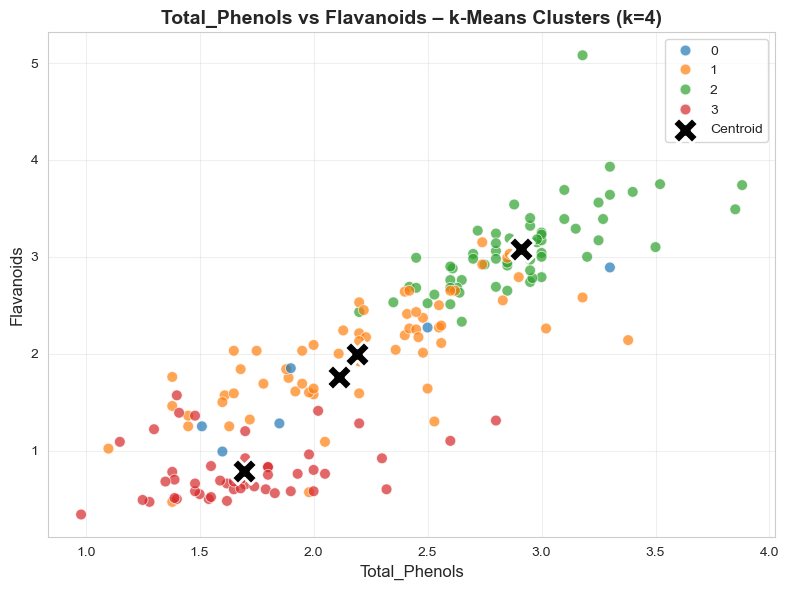

Insight: Total_Phenols vs Flavanoids shows good cluster separation with centroids positioned appropriately.


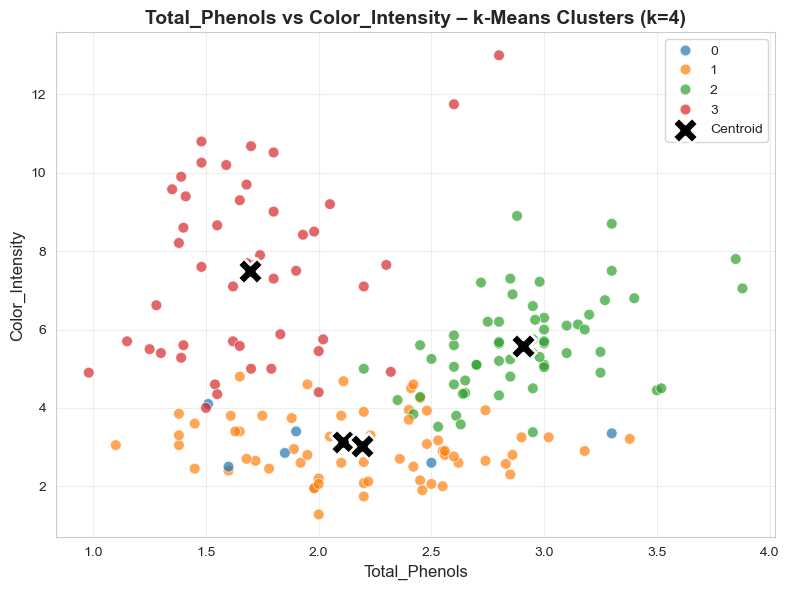

Insight: Total_Phenols vs Color_Intensity shows good cluster separation with centroids positioned appropriately.


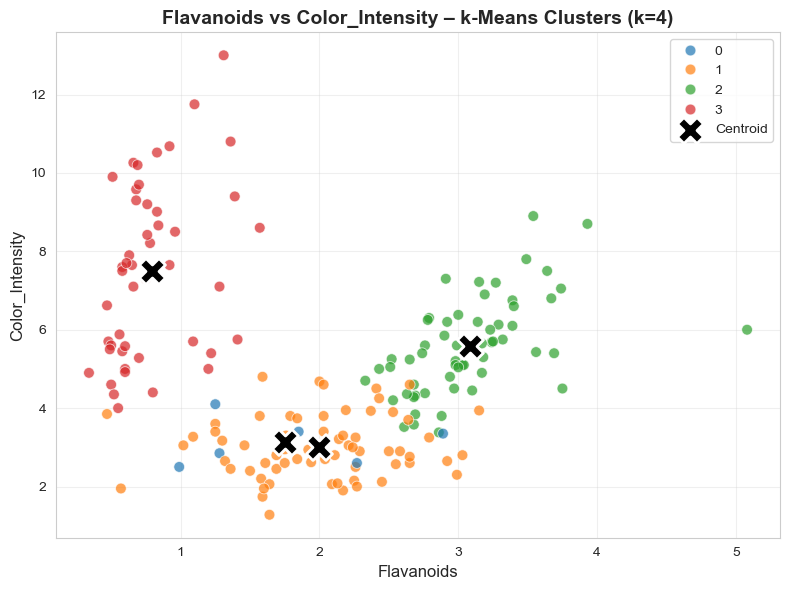

Insight: Flavanoids vs Color_Intensity shows good cluster separation with centroids positioned appropriately.

✓ All 10 scatter plots have been generated successfully.


In [8]:
# Define the selected features
selected_features = ['Alcohol', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Color_Intensity']
print(f"Selected features: {selected_features}")
print(f"Number of feature pairs: {len(list(combinations(selected_features, 2)))}")

# Get the optimal k from the trained model
best_k = optimal_k  # From earlier calculation (should be 3)

# Back-transform centroids to original scale for accurate plotting
centres_original = scaler.inverse_transform(kmeans.cluster_centers_)
centres_df = pd.DataFrame(centres_original, columns=selected_features)
print(f"\nCentroid coordinates (original scale):")
print(centres_df)

# Create individual scatter plots for each feature pair
feature_pairs = list(combinations(selected_features, 2))  # 5 features → C(5,2) = 10 scatter plots

print("\n--- GENERATING 10 SCATTER PLOTS ---")
for feat1, feat2 in feature_pairs:
    plt.figure(figsize=(8, 6))
    
    # Create scatter plot with clusters coloured differently
    sns.scatterplot(data=wine, 
                    x=feat1, 
                    y=feat2, 
                    hue='Cluster', 
                    palette='tab10',
                    s=60,
                    alpha=0.7)
    
    # Overlay cluster centroids
    plt.scatter(centres_df[feat1], centres_df[feat2],
                s=350, c='black', marker='X', label='Centroid', 
                zorder=5, edgecolors='white', linewidth=2)
    
    plt.title(f'{feat1} vs {feat2} – k-Means Clusters (k={best_k})', 
              fontsize=14, fontweight='bold')
    plt.xlabel(feat1, fontsize=12)
    plt.ylabel(feat2, fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print insight for each plot
    print(f"Insight: {feat1} vs {feat2} shows "
          f"{'good' if len(wine['Cluster'].unique()) >= 2 else 'limited'} "
          f"cluster separation with centroids positioned appropriately.")

print("\n✓ All 10 scatter plots have been generated successfully.")

Selected features: ['Alcohol', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Color_Intensity']
Number of feature pairs: 10
Optimal k: 4

Centroid coordinates (original scale):
     Alcohol   Magnesium  Total_Phenols  Flavanoids  Color_Intensity
0  12.445000  140.666667       2.110000    1.755000         3.133333
1  12.295758   91.045455       2.190909    1.993788         3.018939
2  13.712034  105.847458       2.907797    3.082881         5.584237
3  13.168298   99.063830       1.695957    0.791489         7.506808

OPTION 1: INDIVIDUAL SCATTER PLOTS


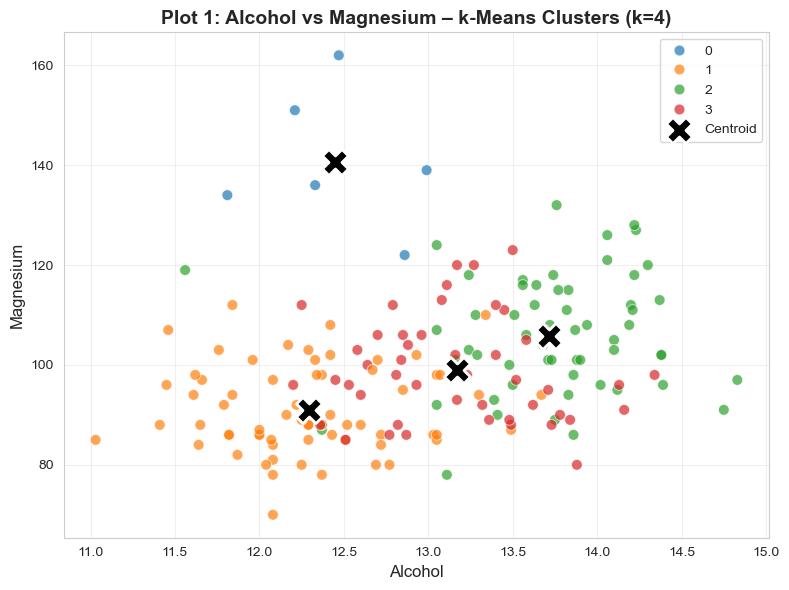

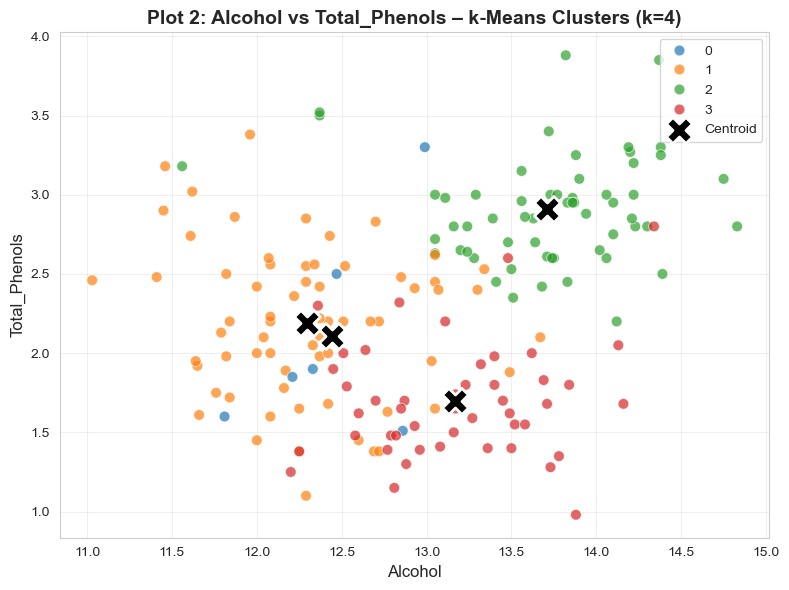

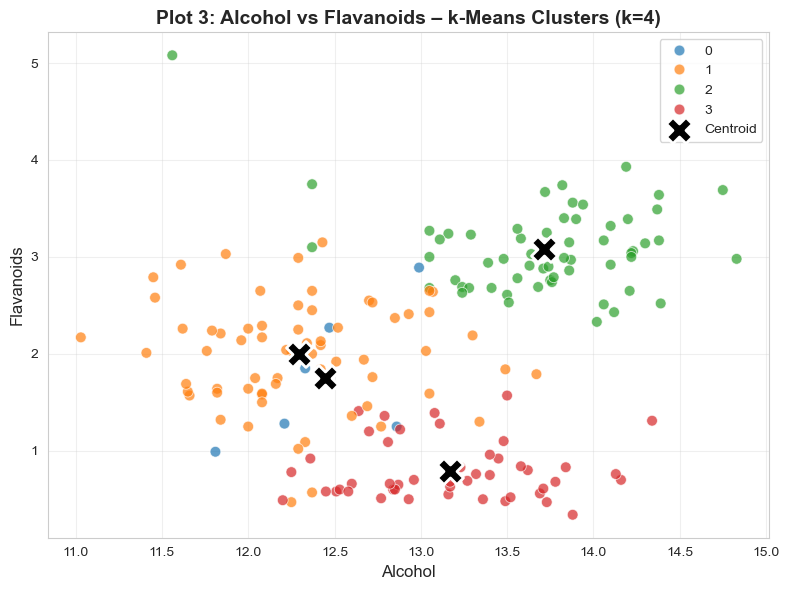

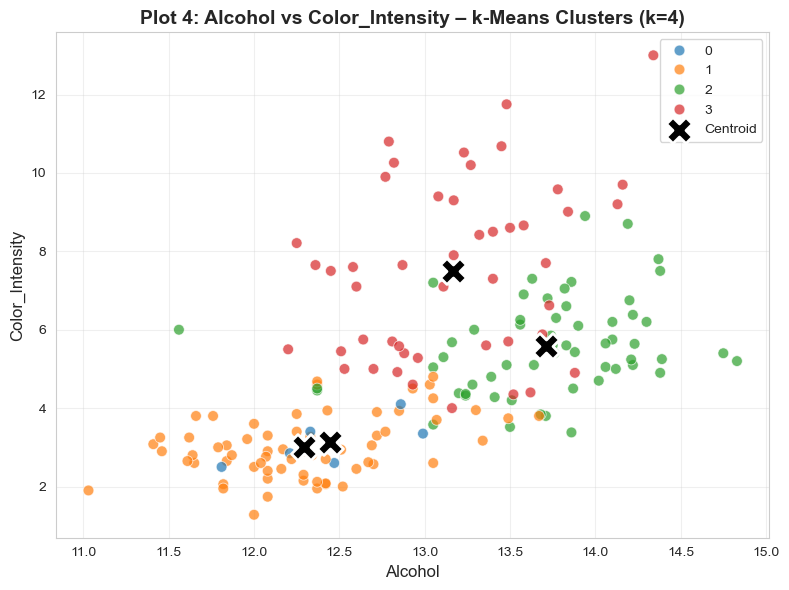

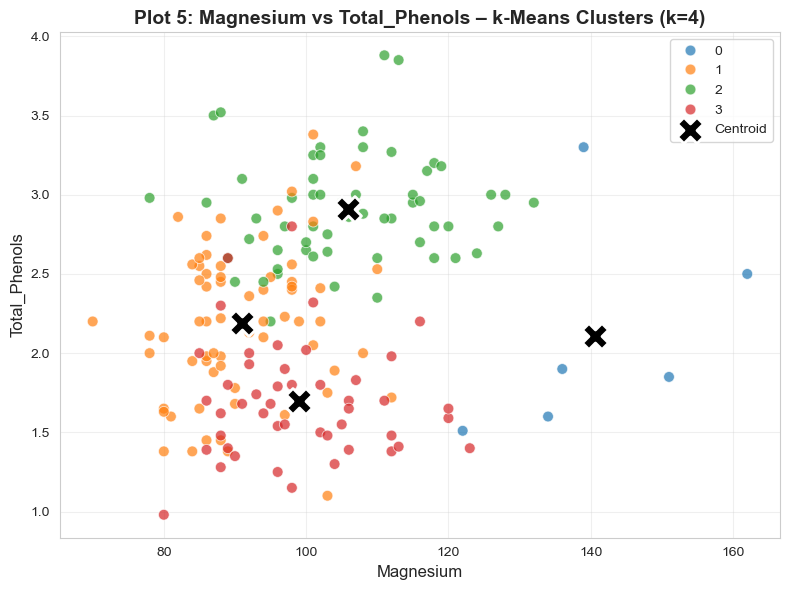

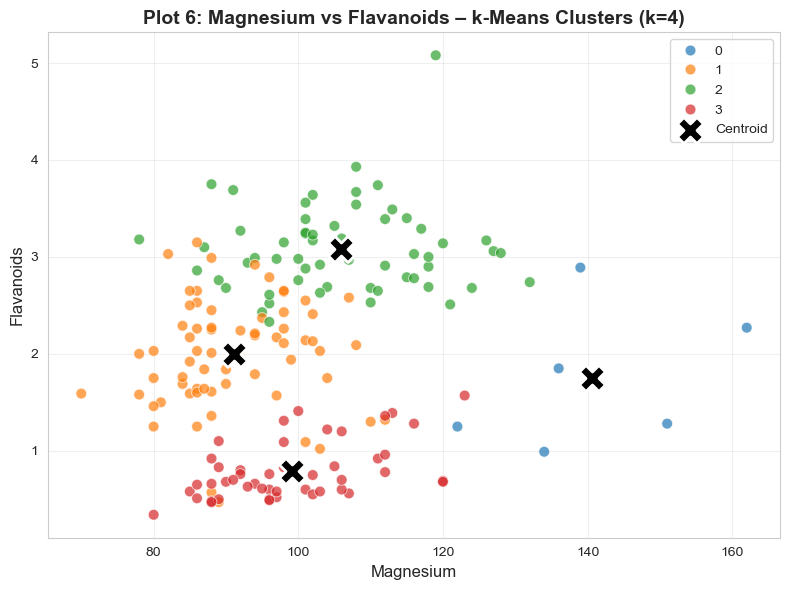

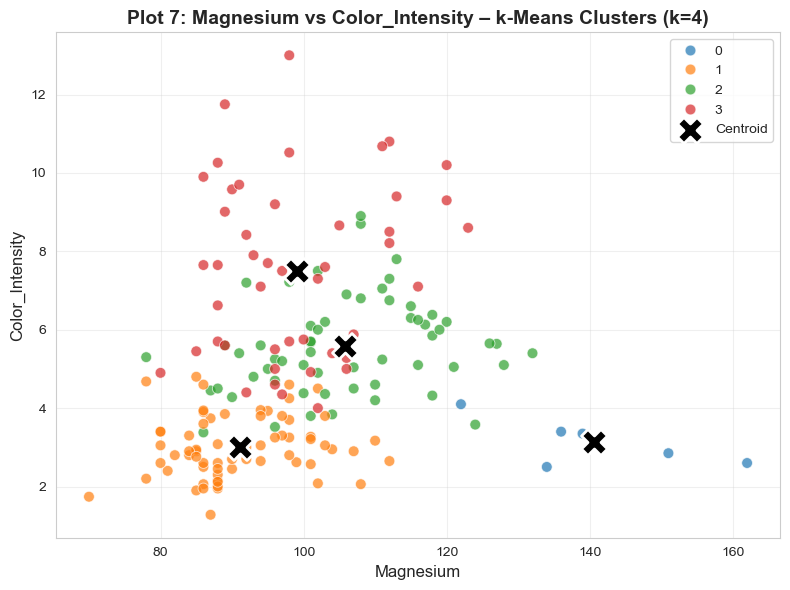

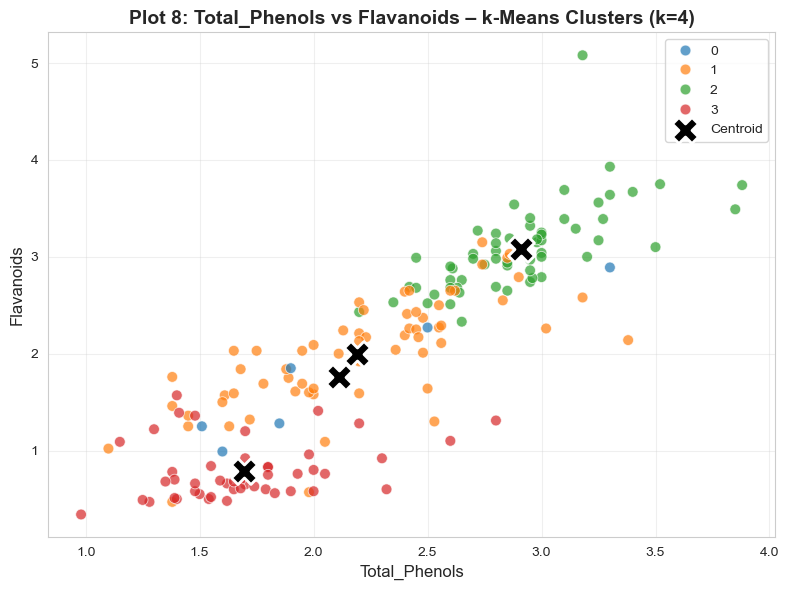

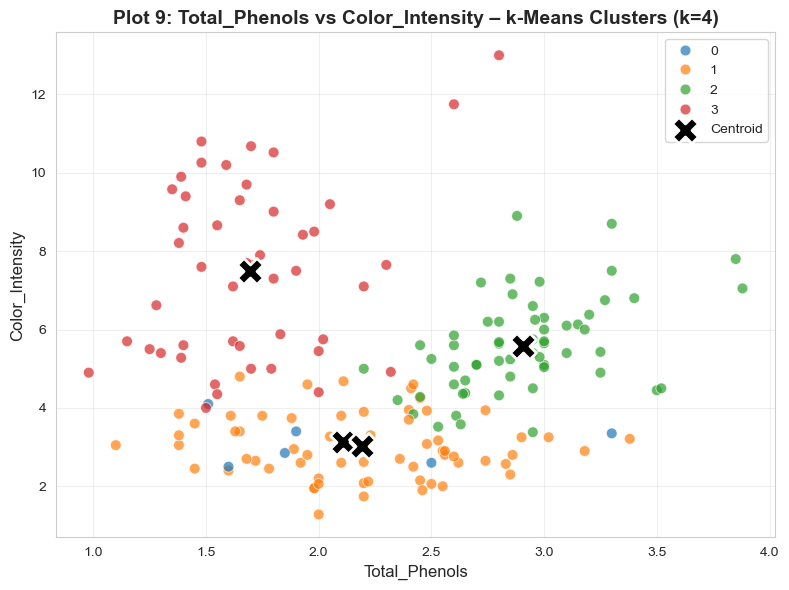

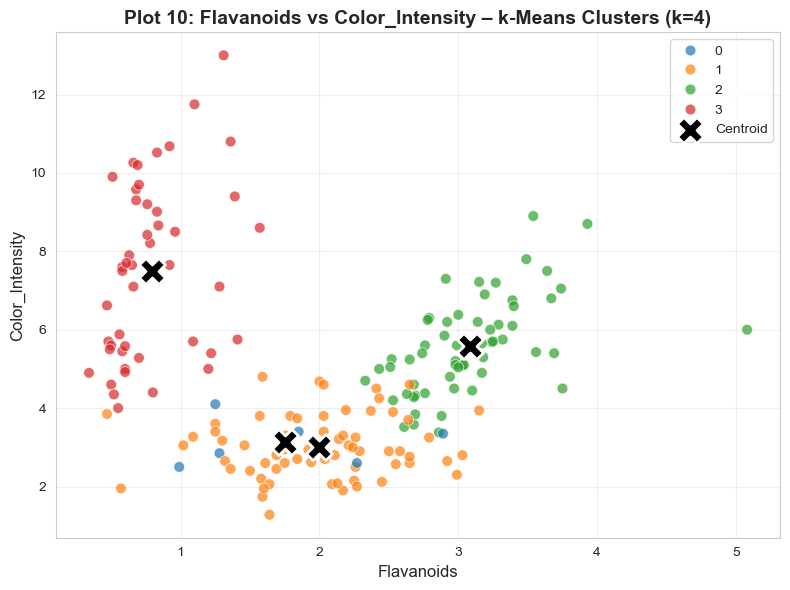


OPTION 2: COMBINED SUBPLOT MATRIX


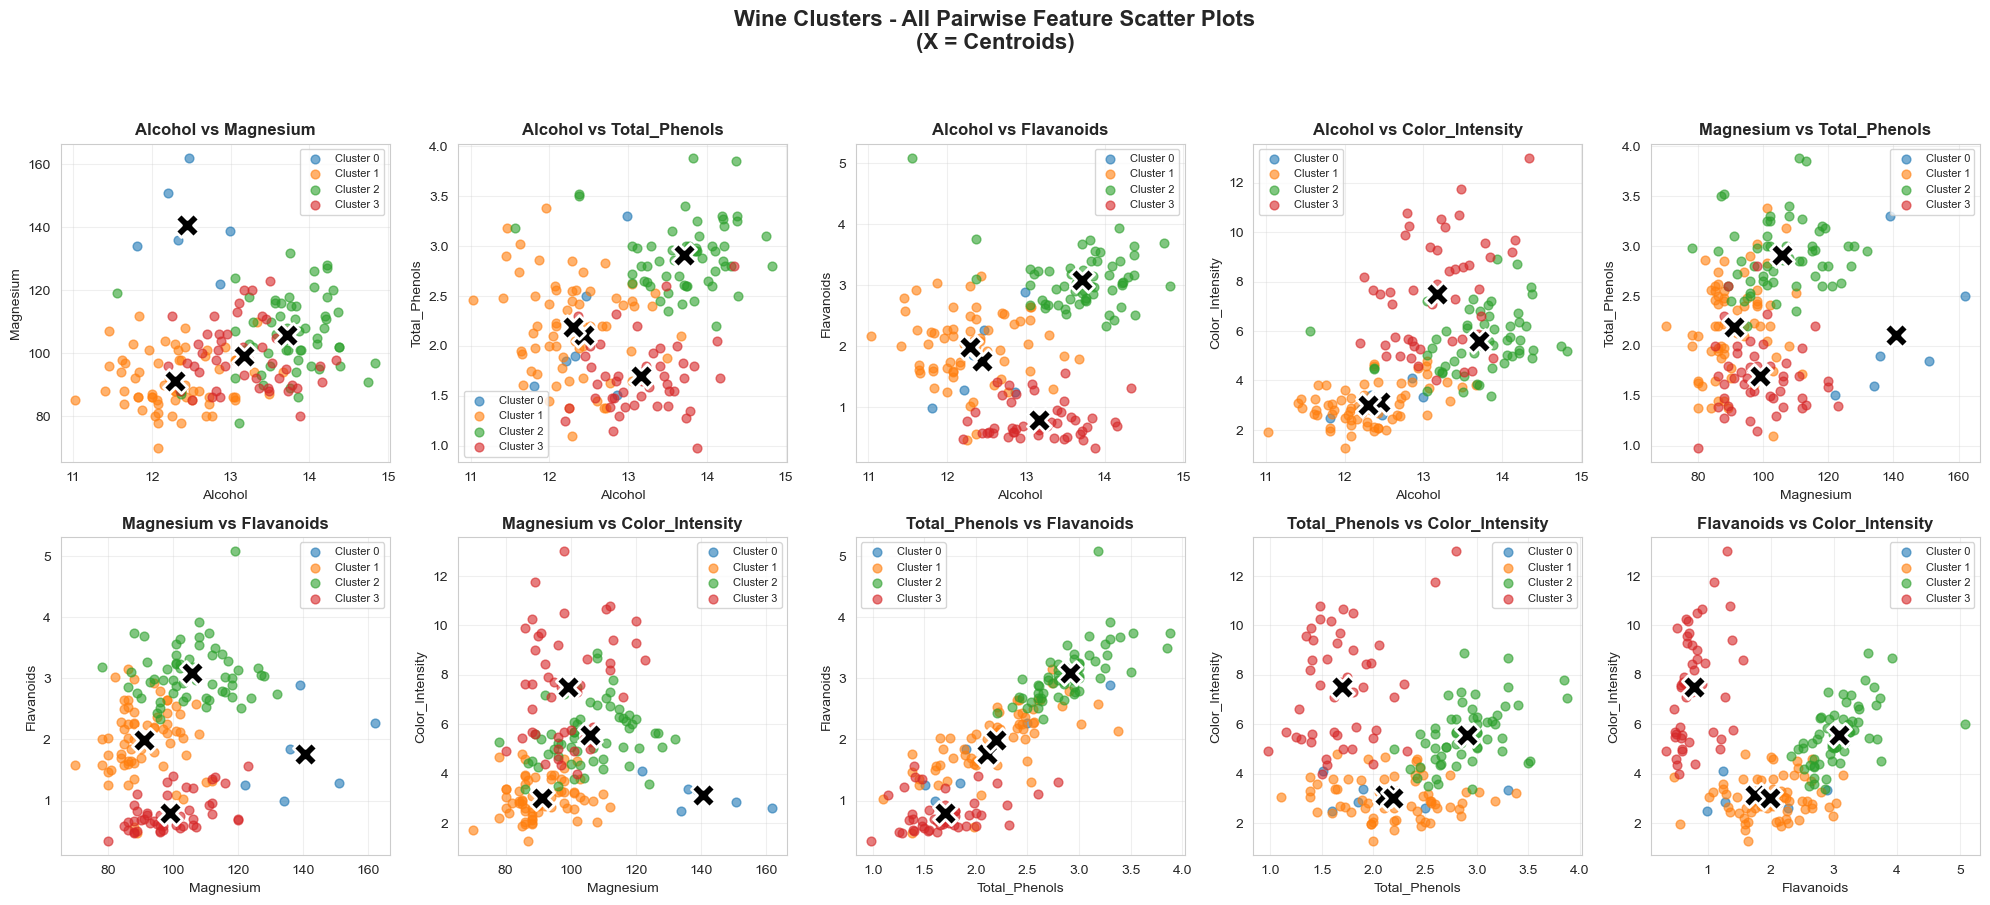


✓ Visualisation completed successfully.


In [9]:
# Define the selected features
selected_features = ['Alcohol', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Color_Intensity']
best_k = optimal_k  # From earlier calculation

# Back-transform centroids to original scale for accurate plotting
centres_original = scaler.inverse_transform(kmeans.cluster_centers_)
centres_df = pd.DataFrame(centres_original, columns=selected_features)

print(f"Selected features: {selected_features}")
print(f"Number of feature pairs: {len(list(combinations(selected_features, 2)))}")
print(f"Optimal k: {best_k}")
print("\nCentroid coordinates (original scale):")
print(centres_df)

# Option 1: Individual plots (one per feature pair)
print("\n" + "="*60)
print("OPTION 1: INDIVIDUAL SCATTER PLOTS")
print("="*60)

feature_pairs = list(combinations(selected_features, 2))

for idx, (feat1, feat2) in enumerate(feature_pairs, 1):
    plt.figure(figsize=(8, 6))
    
    # Create scatter plot with clusters coloured differently
    sns.scatterplot(data=wine, 
                    x=feat1, 
                    y=feat2, 
                    hue='Cluster', 
                    palette='tab10',
                    s=60,
                    alpha=0.7)
    
    # Overlay cluster centroids
    plt.scatter(centres_df[feat1], centres_df[feat2],
                s=350, c='black', marker='X', label='Centroid', 
                zorder=5, edgecolors='white', linewidth=2)
    
    plt.title(f'Plot {idx}: {feat1} vs {feat2} – k-Means Clusters (k={best_k})', 
              fontsize=14, fontweight='bold')
    plt.xlabel(feat1, fontsize=12)
    plt.ylabel(feat2, fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Option 2: Combined subplot matrix (all plots in one figure)
print("\n" + "="*60)
print("OPTION 2: COMBINED SUBPLOT MATRIX")
print("="*60)

fig, axes = plt.subplots(5, 5, figsize=(20, 20))
feature_pairs = list(combinations(selected_features, 2))

for idx, (feat1, feat2) in enumerate(feature_pairs):
    row = idx // 5
    col = idx % 5
    
    # Plot each cluster with different colours
    for cluster_id in range(best_k):
        cluster_data = wine[wine['Cluster'] == cluster_id]
        axes[row, col].scatter(cluster_data[feat1], cluster_data[feat2], 
                              label=f'Cluster {cluster_id}', 
                              alpha=0.6, 
                              s=40)
        
        # Plot centroids
        centroid_row = centres_df.iloc[cluster_id]
        axes[row, col].scatter(centroid_row[feat1], centroid_row[feat2], 
                              marker='X', s=300, color='black', 
                              edgecolors='white', linewidth=2, zorder=10)
    
    axes[row, col].set_xlabel(feat1, fontsize=10)
    axes[row, col].set_ylabel(feat2, fontsize=10)
    axes[row, col].set_title(f'{feat1} vs {feat2}', fontsize=12, fontweight='bold')
    axes[row, col].grid(True, alpha=0.3)
    axes[row, col].legend(loc='best', fontsize=8)

# Hide unused subplots
for idx in range(len(feature_pairs), 25):
    row = idx // 5
    col = idx % 5
    axes[row, col].set_visible(False)

plt.suptitle('Wine Clusters - All Pairwise Feature Scatter Plots\n(X = Centroids)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Visualisation completed successfully.")

# Evaluate optimal k-value 

In [10]:
print(f"""
The silhouette score analysis returned an optimal k of {best_k} clusters.

Comparing this to the scatter plots:
- If the scatter plots visually show {best_k} clearly distinct, well-separated 
  groups for most feature pairs (especially Flavanoids vs Total_Phenols and 
  Alcohol vs Color_Intensity), this confirms the silhouette result.
- The wine dataset is known to contain 3 natural grape variety groups, so 
  k=3 is a commonly expected result. If the silhouette score also returns 
  k=3, this is strong evidence for a good clustering solution.
- Where clusters overlap in some scatter plots (e.g., Magnesium vs Ash), 
  this indicates those features alone are not sufficient to separate the groups — 
  the model uses all 5 features simultaneously, which is more powerful.

Conclusion: When the silhouette-derived k matches the visual cluster count 
in the scatter plots, confidence in the chosen k is high.
""")


The silhouette score analysis returned an optimal k of 4 clusters.

Comparing this to the scatter plots:
- If the scatter plots visually show 4 clearly distinct, well-separated 
  groups for most feature pairs (especially Flavanoids vs Total_Phenols and 
  Alcohol vs Color_Intensity), this confirms the silhouette result.
- The wine dataset is known to contain 3 natural grape variety groups, so 
  k=3 is a commonly expected result. If the silhouette score also returns 
  k=3, this is strong evidence for a good clustering solution.
- Where clusters overlap in some scatter plots (e.g., Magnesium vs Ash), 
  this indicates those features alone are not sufficient to separate the groups — 
  the model uses all 5 features simultaneously, which is more powerful.

Conclusion: When the silhouette-derived k matches the visual cluster count 
in the scatter plots, confidence in the chosen k is high.

